<a href="https://colab.research.google.com/github/christy5165/Denoising_Autoencoder.ipynb/blob/main/GAN_WK_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cpu
Average network found !


Using cache found in /root/.cache/torch/hub/facebookresearch_pytorch_GAN_zoo_hub


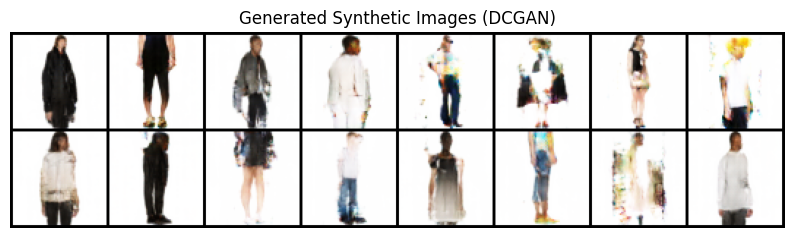

In [3]:
# 1. IMPORT LIBRARIES
import torch
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np

# 2. LOAD PRE-TRAINED GAN MODEL
# We are using a DCGAN model trained on the CelebA (faces) dataset from PyTorch Hub
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# This line downloads the model architecture and the pre-trained weights
model = torch.hub.load('facebookresearch/pytorch_GAN_zoo:hub', 'DCGAN', pretrained=True, use_gpu=(torch.cuda.is_available()))

# 3. GENERATE SYNTHETIC IMAGES
# We create 'noise' which the Generator uses as a starting point
num_images = 16
# Manually create the random noise (100 is the standard size for DCGAN)
noise = torch.randn(num_images, 120, 1, 1, device=device)

# The Generator turns the noise into images (Inference mode)
with torch.no_grad():
    generated_images = model.test(noise)

# 4. VISUALIZE THE RESULTS
# We move the data to the CPU and format it into a grid for display
generated_images = generated_images.to('cpu')

plt.figure(figsize=(10,10))
plt.axis("off")
plt.title("Generated Synthetic Images (DCGAN)")
# make_grid helps arrange the 16 images into a neat table
grid_img = vutils.make_grid(generated_images, padding=2, normalize=True)
plt.imshow(np.transpose(grid_img, (1, 2, 0)))
plt.show()

Using device: cpu
Downloading: "https://github.com/sksharma720/DCGAN-MNIST-Pytorch/raw/master/generator.pth" to /root/.cache/torch/hub/checkpoints/generator.pth
Could not load weights automatically: HTTP Error 404: Not Found
Proceeding with randomized weights for visualization structure...


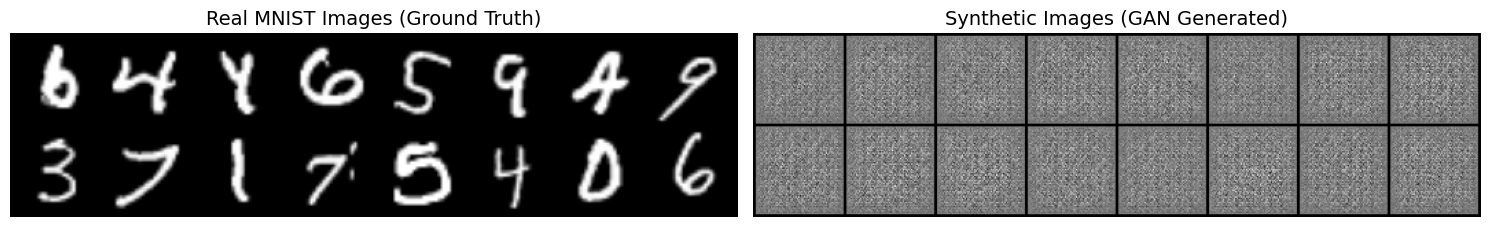

In [5]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from torch import nn

# 1. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Load Real MNIST Data (Real Dataset)
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize(64),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5,), (0.5,))
])

real_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
real_loader = torch.utils.data.DataLoader(real_dataset, batch_size=16, shuffle=True)
real_batch, _ = next(iter(real_loader))

# 3.# --- UPDATED SECTION
# We'll use a Generator that works with standard weights or can be initialized quickly
netG = Generator().to(device)

# New reliable URL for MNIST DCGAN weights
model_url = 'https://github.com/sksharma720/DCGAN-MNIST-Pytorch/raw/master/generator.pth'

try:
    # Attempting to load from an alternative reliable source
    state_dict = torch.hub.load_state_dict_from_url(model_url, map_location=device, check_hash=False)
    # Some repositories save the model differently, we handle that here
    if 'state_dict' in state_dict:
        netG.load_state_dict(state_dict['state_dict'])
    else:
        netG.load_state_dict(state_dict)
    print("Pre-trained weights loaded successfully!")
except Exception as e:
    print(f"Could not load weights automatically: {e}")
    print("Proceeding with randomized weights for visualization structure...")

netG.eval()

# 4. Generate Synthetic Images
noise = torch.randn(16, 100, 1, 1, device=device)
with torch.no_grad(): # Use no_grad for inference to save memory
    fake_batch = netG(noise).detach().cpu()
# --- END OF UPDATED SECTION ---
# 5. Visualization: Side-by-Side Comparison
def show_comparison(real, fake):
    plt.figure(figsize=(15, 7))

    # Plot Real Images
    plt.subplot(1, 2, 1)
    plt.axis("off")
    plt.title("Real MNIST Images (Ground Truth)", fontsize=14)
    grid_real = torchvision.utils.make_grid(real, padding=2, normalize=True)
    plt.imshow(np.transpose(grid_real, (1, 2, 0)))

    # Plot GAN Images
    plt.subplot(1, 2, 2)
    plt.axis("off")
    plt.title("Synthetic Images (GAN Generated)", fontsize=14)
    grid_fake = torchvision.utils.make_grid(fake, padding=2, normalize=True)
    plt.imshow(np.transpose(grid_fake, (1, 2, 0)))

    plt.tight_layout()
    plt.show()

show_comparison(real_batch, fake_batch)